# Neuronové sítě
V tomto cvičení se zaměříme na efektivitu neuronových sítí. Naším úkolem nebude jen se seznámit se základem NN (který možná máte z jiných kurzů), ale zejména s jejich výpočetní náročností zejména při hardwarové implementaci.


## Práce s neuronovou sítí
V prvním kroce musíme načíst požadované knihovny. Budeme pracovat s knihovnou [TensorFlow](https://tesorflow.org) a rozhraním Keras, které by mělo tvořit univerzální rozhraní pro práci s NN.


In [1]:
import tensorflow.keras as keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
import tensorflow.keras.layers as layers
from tensorflow.keras.optimizers import RMSprop

Knihovny jsou úspěšně načtené. Dalším krokem bude stáhnout dataset MNIST obsahující ručně psaná čísla a který je základním benchmarkem pro NN. Tento dataset je (jako ostatní datasety) rozdělen na trénovací data a testovací data.

In [2]:
# the data, split between train and test sets
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28)


Najdeme zde 60 tisíc testovacích a 10 tisíc testovacích obrázků 28x28 pixelů a k tomu odpovídající počet labelů (neboli odpovídajících čísel, které obrázky představují). Bude se tedy jednat o tzv. supervised learning (trénování s učitelem). Tento krátký příklad ukáže, jak data v datasetu vypadají.

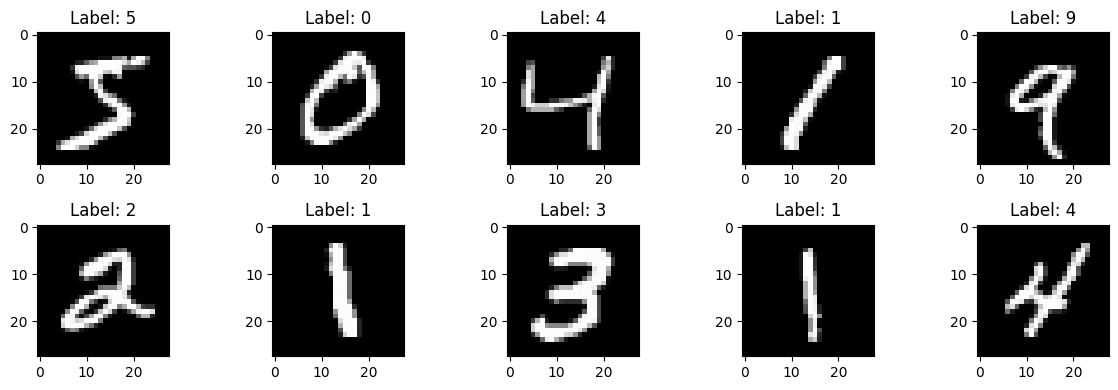

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
for i in range(0, 10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i, :, :].reshape(28, 28), cmap='gray', vmin=0, vmax=255)
    plt.title(f"Label: {y_train[i]:d}")
plt.tight_layout()


Nyní se můžeme dát do konstrukce sítě. Deklarujeme si parametry jako jsou počet batchů (dávek) a počet epoch, po které budeme trénovat

In [4]:
batch_size = 128
epochs = 10

Trénovací data jsou reprezentovány jako byty (0 - 255). My je převedeme do formátu float čísel 0 - 1 a pro MLP síť překonvertujeme 28x28 obrázky do 1D pole o délce 784.

In [5]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

60000 train samples
10000 test samples


Data jsou připravena. Konečně se dostáváme ke konstrukci požadované sítě. Vytvoříme síť plně propojených vrstev: neuronů, kde každý vezme výstupy všech neuronů v předcházející vrstvě a vynásobí je vahou.

![mlp neuron](https://github.com/mrazekv/bin-lab-nn/blob/main/mlp.png?raw=1)

V tomto případě použijeme síť 784-200-100-10 neuronů, kdy všechny kromě poslední budou používat ReLU aktivační funkce.

In [6]:
model1 = Sequential()
model1.add(layers.Input(shape=(784,)))
model1.add(layers.Dense(300, activation='relu'))
model1.add(layers.Dense(10, activation='softmax'))

model2 = Sequential()
model2.add(layers.Input(shape=(784,)))
model2.add(layers.Dense(100, activation='relu'))
model2.add(layers.Dense(10, activation='softmax'))

model3 = Sequential()
model3.add(layers.Input(shape=(784,)))
model3.add(layers.Dense(100, activation='relu'))
model3.add(layers.Dense(100, activation='relu'))
model3.add(layers.Dense(10, activation='softmax'))

model4 = Sequential()
model4.add(layers.Input(shape=(784,)))
model4.add(layers.Dense(300, activation='relu'))
model4.add(layers.Dense(300, activation='relu'))
model4.add(layers.Dense(10, activation='softmax'))

model1.summary()
model2.summary()
model3.summary()
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,510 (931.68 KB)

 Trainable params: 238,510 (931.68 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 300)            │        90,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,810 (1.25 MB)

 Trainable params: 328,810 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Nyní můžeme model zkompilovat a spustit trénování. Tato operace může zabrat nějaký čas, zejména pokud nemáte GPU.

In [7]:
model1.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model1.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model2.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model2.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model3.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model3.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))

model4.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

history = model4.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_test, y_test))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9184 - loss: 0.2882 - val_accuracy: 0.9555 - val_loss: 0.1489
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9646 - loss: 0.1228 - val_accuracy: 0.9705 - val_loss: 0.0981
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9756 - loss: 0.0828 - val_accuracy: 0.9731 - val_loss: 0.0868
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9815 - loss: 0.0620 - val_accuracy: 0.9784 - val_loss: 0.0720
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0485 - val_accuracy: 0.9784 - val_loss: 0.0692
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9889 - loss: 0.0382 - val_accuracy: 0.9806 - val_loss: 0.0669
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9913 - loss: 0.0299 - val_accuracy: 0.9819 - val_loss: 0.0628
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9931 - loss: 0.0244 - val_accuracy: 0.

Model je nyní natrénovaný (na poměrně malý počet epoch). Nyní jej můžeme uložit nebo použít na jednom konkrétním obrázku. Výstupem je 10 hodnot, kdy každá říká pravděpodobnost toho, že obrázek spadá do určité kategorie. Na tomto příkladě můžeme vidět test čísla 9, kdy správně kategorie 9 má největší pravděpodobnost.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


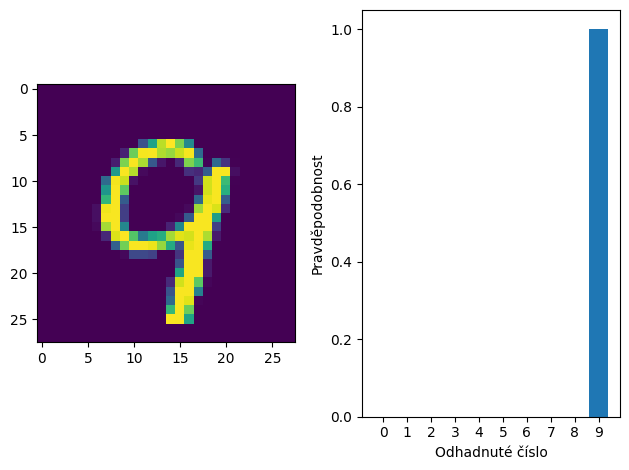

In [8]:
img = x_test[16]
est = model1.predict(img.reshape(1, 784))

plt.subplot(1, 2, 1)
plt.imshow(img.reshape(28, 28), vmin=0, vmax=1)
plt.subplot(1, 2, 2)
plt.bar(range(0, 10), est.reshape(10))
plt.xlabel("Odhadnuté číslo")
plt.ylabel("Pravděpodobnost")
plt.xticks(range(0, 10))
plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


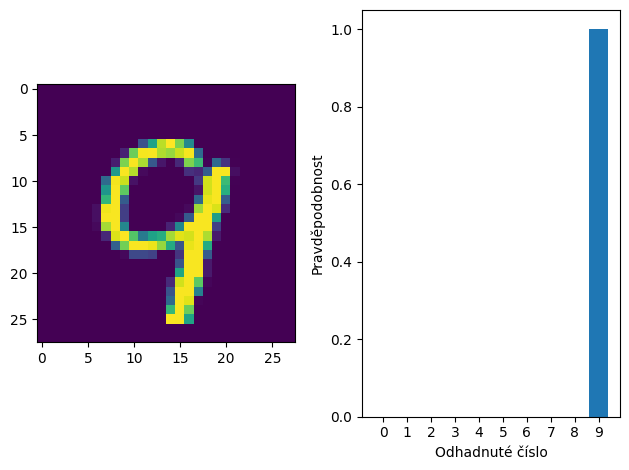

In [9]:
img = x_test[16]
est = model2.predict(img.reshape(1, 784))

plt.subplot(1, 2, 1)
plt.imshow(img.reshape(28, 28), vmin=0, vmax=1)
plt.subplot(1, 2, 2)
plt.bar(range(0, 10), est.reshape(10))
plt.xlabel("Odhadnuté číslo")
plt.ylabel("Pravděpodobnost")
plt.xticks(range(0, 10))
plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


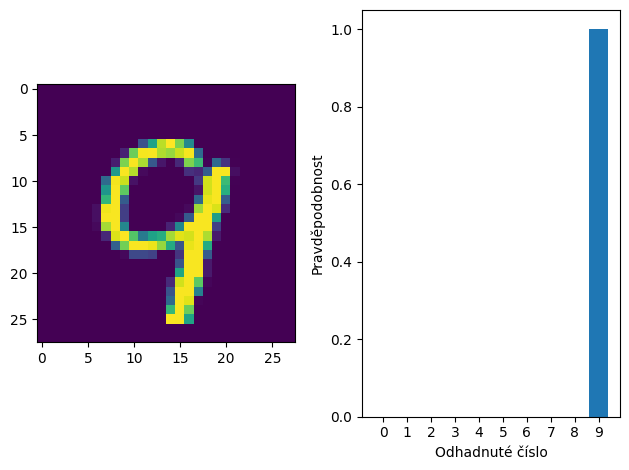

In [10]:
img = x_test[16]
est = model3.predict(img.reshape(1, 784))

plt.subplot(1, 2, 1)
plt.imshow(img.reshape(28, 28), vmin=0, vmax=1)
plt.subplot(1, 2, 2)
plt.bar(range(0, 10), est.reshape(10))
plt.xlabel("Odhadnuté číslo")
plt.ylabel("Pravděpodobnost")
plt.xticks(range(0, 10))
plt.tight_layout()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step


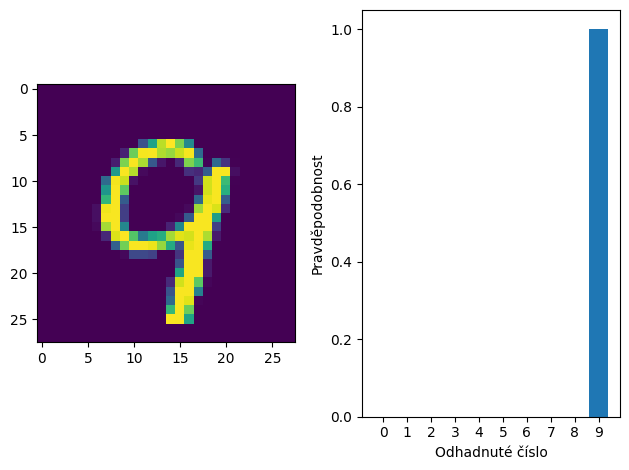

In [11]:
img = x_test[16]
est = model4.predict(img.reshape(1, 784))

plt.subplot(1, 2, 1)
plt.imshow(img.reshape(28, 28), vmin=0, vmax=1)
plt.subplot(1, 2, 2)
plt.bar(range(0, 10), est.reshape(10))
plt.xlabel("Odhadnuté číslo")
plt.ylabel("Pravděpodobnost")
plt.xticks(range(0, 10))
plt.tight_layout()

In [12]:
score = model1.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model2.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model3.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

score = model4.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.062096696346998215
Test accuracy: 0.9822999835014343
Test loss: 0.07823110371828079
Test accuracy: 0.9771000146865845
Test loss: 0.0719432607293129
Test accuracy: 0.9800000190734863
Test loss: 0.08188462257385254
Test accuracy: 0.9811999797821045


In [13]:
import pandas as pd

network_types = {
    'Model 1': 'MLP (784-300-10)',
    'Model 2': 'MLP (784-100-10)',
    'Model 3': 'MLP (784-100-100-10)',
    'Model 4': 'MLP (784-300-300-10)'
}

validation_accuracy = {
    'Model 1': 0.9805,
    'Model 2': 0.9757,
    'Model 3': 0.9761,
    'Model 4': 0.9822
}

# Model 1: (784*300) + (300*10) = 235200 + 3000 = 238200
# Model 2: (784*100) + (100*10) = 78400 + 1000 = 79400
# Model 3: (784*100) + (100*100) + (100*10) = 78400 + 10000 + 1000 = 89400
# Model 4: (784*300) + (300*300) + (300*10) = 235200 + 90000 + 3000 = 328200
multiplications_fc = {
    'Model 1': 238200,
    'Model 2': 79400,
    'Model 3': 89400,
    'Model 4': 328200
}

# Since these are MLP models, there are no convolutional layers
multiplications_conv = {
    'Model 1': 0,
    'Model 2': 0,
    'Model 3': 0,
    'Model 4': 0
}

trainable_params = {
    'Model 1': 238510,
    'Model 2': 79510,
    'Model 3': 89610,
    'Model 4': 328810
}

data = {
    'Typ sítě': [network_types[f'Model {i}'] for i in range(1, 5)],
    'Validační přesnost (10 epoch)': [validation_accuracy[f'Model {i}'] for i in range(1, 5)],
    'Počet násobení ve FC vrstvách': [multiplications_fc[f'Model {i}'] for i in range(1, 5)],
    'Počet násobení v konvolučních vrstvách': [multiplications_conv[f'Model {i}'] for i in range(1, 5)],
    'Počet trénovacích parametrů': [trainable_params[f'Model {i}'] for i in range(1, 5)]
}

df = pd.DataFrame(data, index=[f'Model {i}' for i in range(1, 5)])

print(df.to_markdown(floatfmt=".4f"))

|         | Typ sítě             |   Validační přesnost (10 epoch) |   Počet násobení ve FC vrstvách |   Počet násobení v konvolučních vrstvách |   Počet trénovacích parametrů |
|:--------|:---------------------|--------------------------------:|--------------------------------:|-----------------------------------------:|------------------------------:|
| Model 1 | MLP (784-300-10)     |                          0.9805 |                          238200 |                                        0 |                        238510 |
| Model 2 | MLP (784-100-10)     |                          0.9757 |                           79400 |                                        0 |                         79510 |
| Model 3 | MLP (784-100-100-10) |                          0.9761 |                           89400 |                                        0 |                         89610 |
| Model 4 | MLP (784-300-300-10) |                          0.9822 |                          328200 |        